In [1]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel,AutoModelForCausalLM
from sklearn.mixture import GaussianMixture
def load_model_and_tokenizer(model_name, device, torch_dtype=torch.float16):
    """prepare LLM and tokenizer"""

    model = AutoModelForCausalLM.from_pretrained(model_name, attn_implementation="sdpa", torch_dtype=torch_dtype, low_cpu_mem_usage=True).to(device)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    tokenizer.pad_token = tokenizer.eos_token
    model.config.pad_token_id = model.config.eos_token_id
    
    return model, tokenizer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model,tokenizer=load_model_and_tokenizer("Qwen/Qwen2.5-7B-Instruct",device)

# Example Datasets (same as before)
factual_prompts = [
    "What is the capital of France?",
    "Who wrote the play Hamlet?",
    "What is the chemical formula for water?",
    "Define the theory of relativity.",
    "Explain the process of photosynthesis.",
    "What year did the Titanic sink?",
    "Who was the first person to walk on the moon?",
    "What is the boiling point of water in Celsius?",
    "Describe the function of the mitochondria.",
    "Who painted the Mona Lisa?",
]

test_prompts = [
    "What is the largest planet in our solar system?", # Factual
    "Who is the prime minister of Japan?", # Factual
    "Tell me about the key events of World War II.", # Borderline
    "Write a short story about a futuristic city.", # Creative
    "Invent a new type of pasta and describe it.", # Creative
    "What if dinosaurs never went extinct?", # Creative
    "Compose a lullaby for a baby robot.", # Creative
]


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
def get_chat(model_name: str, question: str):
    """Creates the chat structure for different LLMs."""
    # This is a simplified version of your prompt formatting.
    # In your real code, you might have more complex logic in INSTRUCT.
    prompt = f"Q: {question} A:"
    
    # Based on your get_chat function for Gemma
    chat = [
        {"role": "user", "content": prompt},
    ]
    return chat
def get_prompt_embedding_formatted(prompt_text: str, tokenizer, model, model_name: str = "gemma"):
    """
    Computes the hidden state for a prompt AFTER applying the chat template.
    This is the CORRECT way to get a meaningful prompt embedding for classification.
    """
    # 1. Create the chat dictionary structure
    chat = get_chat(model_name, prompt_text)
    
    # 2. Apply the model-specific chat template
    # This adds special tokens like <start_of_turn>user...
    formatted_prompt = tokenizer.apply_chat_template(
        chat, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    # 3. Tokenize the fully formatted prompt
    inputs = tokenizer(formatted_prompt, return_tensors="pt").to(model.device)

    # 4. Get the hidden states from the model
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # 5. Extract the embedding of the LAST token
    hidden_states = outputs.hidden_states[-1]
    embedding = hidden_states[0, -1, :]
    
    return embedding

In [3]:
from datasets import load_dataset
ds = load_dataset("truthfulqa/truthful_qa", "generation", split="validation")
factual_prompts=[prompt for prompt in ds["question"]]

In [4]:
import json
with open("data/instructions/train_val/jailbreak_train.json", 'r') as f:
    data = json.load(f)
    prompts = [item["query"] for item in data]


In [5]:

# train_test_split = ds.train_test_split(test_size=0.5, seed=0)
# train_ds = train_test_split["train"]
# test_ds = train_test_split["test"]

In [6]:
train_prompts=prompts[:1000]
test_prompt=prompts[1000:2000]

In [7]:
with open("data/instructions/train_val/harmful_train_1000.json", 'r') as f:
    data = json.load(f)
    prompts_2 = [item["query"] for item in data]


In [8]:
train_prompts=train_prompts+prompts_2

In [9]:
len(train_prompts)

2000

In [10]:

# factual_prompts_train=[prompt for prompt in train_ds["question"]]
# factual_prompts_test=[prompt for prompt in test_ds["question"]]
# activation=[get_prompt_embedding_formatted(i,tokenizer,model) for i in factual_prompts_train]
# activation=torch.stack(activation)
# activation=activation.to(torch.float32)
# activation.shape

from tqdm.notebook import tqdm

# 使用tqdm包装train_prompts来显示进度条
activation = [get_prompt_embedding_formatted(i, tokenizer, model) for i in tqdm(train_prompts, desc="处理训练提示")]


处理训练提示:   0%|          | 0/2000 [00:00<?, ?it/s]

In [11]:
activation=torch.stack(activation)
activation=activation.to(torch.float32)
activation.shape

torch.Size([2000, 3584])

In [12]:
# # --- 1. 实现你的“比较距离”方法 ---
# def get_qa_score(h, VK):
#     """
#     计算一个向量h的能量在QA子空间和其正交补空间中的分布，
#     并返回其在QA子空间中的能量占比。
#     h: shape (1, d)
#     Vk: shape (d, k)
#     """
#     # 1. 计算在QA子空间的分量 h_qa
#     # h_qa = h @ Vk @ Vk.T  <-- 这是一个 (1, d) 的向量
#     # 我们需要的是能量，可以直接计算投影坐标
#     coords_qa = h @ VK@ VK.T # (1, k)
#     energy_qa = torch.sum(coords_qa**2) # ||h_qa||^2

#     # 2. 计算总能量
#     total_energy = torch.sum(h**2) # ||h||^2
    
#     # 避免除以零
#     if total_energy < 1e-9:
#         return 0.0

#     # 3. 计算能量占比分数
#     score = energy_qa / total_energy
#     return score


In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=128)
pca.fit(activation.detach().cpu().numpy())
VK = pca.components_.T
VK=torch.tensor(VK).to(torch.device("cuda"))
VK=VK.to(torch.float32)

In [14]:
# # --- 1. 实现你的“比较距离”方法 ---
# def get_qa_score(h, VK):
#     """
#     计算一个向量h的能量在QA子空间和其正交补空间中的分布，
#     并返回其在QA子空间中的能量占比。
#     h: shape (1, d)
#     Vk: shape (d, k)
#     """
#     # 1. 计算在QA子空间的分量 h_qa
#     # h_qa = h @ Vk @ Vk.T  <-- 这是一个 (1, d) 的向量
#     # 我们需要的是能量，可以直接计算投影坐标
#     coords_qa = h @ VK@ VK.T # (1, k)
#     energy_qa = torch.sum(coords_qa**2) # ||h_qa||^2

#     # 2. 计算总能量
#     total_energy = torch.sum(h**2) # ||h||^2
    
#     # 避免除以零
#     if total_energy < 1e-9:
#         return 0.0

#     # 3. 计算能量占比分数
#     score = energy_qa / total_energy
#     return score
# activation=activation.to(torch.float32)
# factual_scores=[get_qa_score(prompt, VK) for prompt in activation]
# factual_scores=torch.stack(factual_scores)
# factual_scores.shape

In [15]:
# count = (factual_scores < 0.5).sum().item()
# count

In [16]:
# factual_prompts_test=[prompt for prompt in test_ds["question"]]
# activation_test=[get_prompt_embedding_formatted(i,tokenizer,model) for i in factual_prompts_test]
# activation_test=torch.stack(activation_test)
# activation_test=activation_test.to(torch.float32)
with open("data/instructions/train_val/benign_train.json", 'r') as f:
    data = json.load(f)
    prompts = [item["query"] for item in data]


In [17]:
test_prompts=prompts[:1000]

In [18]:
with open("data/instructions/test/xstest_safe.json", 'r') as f:
    data = json.load(f)
    prompts = [item["prompt"] for item in data]

In [19]:
test_prompts=prompts[:200]+test_prompts

In [20]:
len(test_prompts)

1200

In [21]:
with open("data/instructions/test/alpaca_eval.json", 'r') as f:
    data = json.load(f)
    prompts = [item["instruction"] for item in data]

In [22]:
test_prompts=prompts[:500]+test_prompts
len(test_prompts)

1700

In [23]:
with open("data/instructions/test/gsm8k_test_sampled.json", 'r') as f:
    data = json.load(f)
    prompts = [item["problem"] for item in data]

In [24]:
test_prompts=prompts+test_prompts
len(test_prompts)

1800

In [25]:
with open("data/instructions/test/math_500_sampled.json", 'r') as f:
    data = json.load(f)
    prompts = [item["problem"] for item in data]

In [26]:
test_prompts=prompts+test_prompts
len(test_prompts)

1900

In [27]:
neg_questions=[get_prompt_embedding_formatted(prompt,tokenizer,model) for prompt in tqdm(test_prompts, desc="处理测试提示")]

处理测试提示:   0%|          | 0/1900 [00:00<?, ?it/s]

In [28]:

neg_questions=torch.stack(neg_questions)
neg_questions=neg_questions.to(torch.float32)


In [29]:
neg_questions.shape

torch.Size([1900, 3584])

In [30]:
# from datasets import load_dataset

# def load_mmlu_sampled_questions(subsets=None, num_samples=20, split="dev"):
#     """
#     从指定学科中抽取一定数量的样本（默认 20）
#     - subsets: 学科名的列表
#     - num_samples: 每个学科抽取的样本数
#     - split: 'test', 'dev', 或 'validation' （MMLU 支持这三个划分）
#     返回：包含所有学科问题的列表
#     """
#     all_questions = []
    
#     # 遍历学科并抽取样本
#     for subject in subsets:
#         # 加载指定学科数据集
#         ds = load_dataset("cais/mmlu", subject, split=split)
#         print(subject)
#         # 从每个学科中抽取 `num_samples` 个样本
#         sampled_ds = ds.select(range(min(num_samples, len(ds))))
        
#         # 将抽取的问题添加到所有问题列表中
#         all_questions.extend(sampled_ds["question"])

#     return all_questions

# if __name__ == "__main__":
#     # 示例学科
#     subjects = ['abstract_algebra', 'all', 'anatomy', 'astronomy', 
#                 'business_ethics', 'clinical_knowledge', 'college_biology', 'college_chemistry', 
#                 'college_computer_science']
    
#     # 抽取并合并 20 个问题
#     questions = load_mmlu_sampled_questions(subjects, num_samples=20, split="dev")
    
#     # 输出合并后的问题列表
#     print(f"总共抽取了 {len(questions)} 个问题")
#     print(questions[:5])  # 输出前 5 个问题作为示例


In [31]:
import json
def load_json_file( prompt_column="prompt", file_path=None):
    file_path = file_path 
    if not file_path:
        print("错误：未提供输入文件路径")
        return None
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            data = json.load(file)
            if isinstance(data, list) and all(isinstance(item, dict) and prompt_column in item for item in data):
                prompts_list = [item[prompt_column] for item in data]
                print(f"成功加载 {len(prompts_list)} 个prompts。")
                return prompts_list
            else:
                print(f"错误：文件 '{file_path}' 的格式不符合预期。")
                return None
    except FileNotFoundError:
        print(f"错误：找不到文件 '{file_path}'")
        return None
    except json.JSONDecodeError:
        print(f"错误：文件 '{file_path}' 不是有效的JSON格式")
        return None
    except Exception as e:
        print(f"加载JSON文件时发生错误：{e}")
        return None

In [32]:
questions=load_json_file("instruction","data/instructions/test/alpaca_eval.json")

成功加载 805 个prompts。


In [33]:
test_questions=[get_prompt_embedding_formatted(prompt,tokenizer,model) for prompt in questions]
test_questions=torch.stack(test_questions)
test_questions=test_questions.to(torch.float32)


In [34]:
test_questions.shape

torch.Size([805, 3584])

In [35]:
import numpy as np

# 假设test_questions是您的原始数据，形状为[805,3584]
# 如果test_questions还不是numpy数组，可以先转换
# test_questions = np.array(test_questions)

# 获取数据总数
total_samples = test_questions.shape[0]  # 805个样本

# 计算训练集和测试集的大小
train_size = int(total_samples * 0.7)  # 70%作为训练集

# 生成随机索引
indices = np.random.permutation(total_samples)

# 分割索引
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# 根据索引分割数据
train_set = test_questions[train_indices]
test_set = test_questions[test_indices]

# 验证结果
print(f"原始数据形状: {test_questions.shape}")
print(f"训练集形状: {train_set.shape}")  # 应该是[81, 3584]（因为805*0.1≈80.5，取整为81）
print(f"测试集形状: {test_set.shape}")  # 应该是[724, 3584]（805-81=724）

原始数据形状: torch.Size([805, 3584])
训练集形状: torch.Size([563, 3584])
测试集形状: torch.Size([242, 3584])


In [36]:
import torch
from typing import Optional, Tuple

class EnergyGateVK:
    """
    Inference-time adaptive gate using an orthonormal basis VK ∈ R^{D×K}.
    Score s(h) = ||V^T (h - m)||^2 / ||h - m||^2 ∈ [0,1]  (if use_centering=True; else m=0)
    Probability p = sigmoid(w*s + b), decision steer = (p >= 0.5).
    The 'learnable threshold' on s is tau = -b / w, which changes as (w,b) are trained.
    """
    def __init__(
        self,
        VK: torch.Tensor,                       # [D, K]  columns ≈ orthonormal
        device: Optional[torch.device] = None,
        dtype: torch.dtype = torch.float32,
        init_w: float = 4.0,
        init_b: float = -2.0,
        orthonormalize: bool = False,          # True -> run QR to enforce orthonormal columns
        use_centering: bool = False,           # True -> subtract mean before scoring
        mean_vec: Optional[torch.Tensor] = None  # [D], required if use_centering=True and you want PCA-consistent scores
    ):
        self.device = device or VK.device
        self.dtype  = dtype
        self.orthonormalize=orthonormalize
        VK = VK.to(self.device, self.dtype)
        if orthonormalize:
            # QR with economic mode to orthonormalize columns
            Q, _ = torch.linalg.qr(VK, mode='reduced')  # Q: [D,K]
            VK = Q
        self.VK = VK                                    # [D,K]

        self.use_centering = bool(use_centering)
        if self.use_centering:
            assert mean_vec is not None, "use_centering=True requires mean_vec."
            self.mean_vec = mean_vec.to(self.device, self.dtype)  # [D]
        else:
            self.mean_vec = torch.zeros(VK.shape[0], device=self.device, dtype=self.dtype)

        # trainable scalar parameters (stored as tensors with grad)
        self.w = torch.tensor(float(init_w), device=self.device, dtype=self.dtype, requires_grad=True)
        self.b = torch.tensor(float(init_b), device=self.device, dtype=self.dtype, requires_grad=True)

    # ---------- core scoring ----------
    @torch.no_grad()
    def energy_ratio(self, h: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
        """
        s = ||V^T (h - mean)||^2 / ||h - mean||^2, returns [N], clipped to [0,1].
        Assumes columns of VK are orthonormal (V^T V = I).
        """
        h = h.to(self.device, self.dtype)           # [N,D] or [D] -> will handle [N,D]
        if h.dim() == 1:
            h = h.unsqueeze(0)
        h_c = h - self.mean_vec                         # [N,D]
        coeff = h_c @ self.VK                       # [N,K] ~= V^T h_c
        num = (coeff * coeff).sum(dim=-1)           # ||V^T h_c||^2
        den = (h_c * h_c).sum(dim=-1).clamp_min(eps)# ||h_c||^2
        return (num / den).clamp_(0.0, 1.0)         # [N]

    @torch.no_grad()
    def predict_proba(self, h: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns (s, p) with shapes [N].
        """
        s = self.energy_ratio(h)
        p = torch.sigmoid(self.w * s + self.b)
        return s, p

    @torch.no_grad()
    def decide(self, h: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns (s, p, steer_bool) where steer_bool is [N] boolean.
        """
        s, p = self.predict_proba(h)
        steer = p >= 0.5
        return s, p, steer
        # ---------- threshold utilities ----------
    @torch.no_grad()
    def tau_from_pos(self, pos: torch.Tensor, recall_target: float = 0.90) -> float:
        """
        Set tau so that about recall_target of positive samples satisfy s >= tau.
        Uses quantile: tau = Quantile_{1 - recall_target}(s_pos)
        """
        pos = pos.to(self.device, self.dtype)
        s_pos = self.energy_ratio(pos)  # [N_pos]
        q = torch.quantile(s_pos, q=1.0 - recall_target)
        return float(q.clamp_(0.0, 1.0).item())

    @torch.no_grad()
    def set_threshold(self, tau: float):
        """
        Set the decision boundary to p=0.5 at a desired s=tau by updating b = -w * tau.
        """
        tau = float(max(0.0, min(1.0, tau)))
        self.b.copy_(-self.w * tau)

    @torch.no_grad()
    def reset_by_tau(self, tau: float, w_init: Optional[float] = None):
        """
        Reset (w, b) to start at a given tau: b = -w * tau.
        Optionally reset w as well.
        """
        if w_init is not None:
            self.w.copy_(torch.tensor(float(w_init), device=self.device, dtype=self.dtype))
        if abs(float(self.w.item())) < 1e-6:
            self.w.copy_(torch.tensor(4.0, device=self.device, dtype=self.dtype))
        self.set_threshold(tau)

    @torch.no_grad()
    def initialize_tau_by_pos(self, pos: torch.Tensor, recall_target: float = 0.90, w_init: Optional[float] = 4.0):
        """
        One-shot: choose tau from positives and reset (w,b) accordingly.
        """
        tau0 = self.tau_from_pos(pos, recall_target=recall_target)
        self.reset_by_tau(tau0, w_init=w_init)
        return tau0
    # ---------- training ----------
    def _batch_loss(self, s: torch.Tensor, y: torch.Tensor, lam: float) -> torch.Tensor:
        # BCE with logits over logits = w*s + b
        logits = self.w * s + self.b
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, y)
        if lam > 0:
            loss = loss + lam * (self.w * self.w + self.b * self.b)
        return loss

    def fit(
        self,
        pos: torch.Tensor,                  # [N_pos, D]
        neg: torch.Tensor,                  # [N_neg, D]
        lr: float = 1e-3,
        lam: float = 1e-4,
        epochs: int = 3,
        batch_size: int = 4096,
        shuffle: bool = True,
        auto_init_tau: bool = True,
        recall_target: float = 0.90,
        optimizer: str = "adam"
    ):
        """
        Supervised training on positives/negatives (sizes may differ).
        Only (w,b) are optimized; VK/mean are fixed.
        """
        # X = torch.cat([pos.to(self.device, self.dtype),
        #                neg.to(self.device, self.dtype)], dim=0)  # [N,D]
        # y = torch.cat([torch.ones(len(pos), device=self.device, dtype=self.dtype),
        #                torch.zeros(len(neg), device=self.device, dtype=self.dtype)], dim=0)

        
        if auto_init_tau and len(pos) > 0:
            self.initialize_tau_by_pos(pos, recall_target=recall_target, w_init=float(self.w.item()))
        params = [self.w, self.b]
        if optimizer.lower() == "adam":
            opt = torch.optim.Adam(params, lr=lr)
        else:
            opt = torch.optim.SGD(params, lr=lr)

        for _ in range(max(1, epochs)):
            current_pos = pos.to(self.device, self.dtype)
            current_neg = neg.to(self.device, self.dtype)
            
            # 每轮都重新配对pos和neg
            X = torch.cat([current_pos, current_neg], dim=0)  # [N,D]
            y = torch.cat([torch.ones(len(current_pos), device=self.device, dtype=self.dtype),
                        torch.zeros(len(current_neg), device=self.device, dtype=self.dtype)], dim=0)
            N = X.size(0)
            indices = torch.randperm(N, device=self.device)
            for start in range(0, N, batch_size):
                sl = indices[start:start+batch_size]
                h = X[sl]                                 # [B,D]
                s = self.energy_ratio(h)                  # [B]
                target = y[sl]                            # [B]
                opt.zero_grad(set_to_none=True)
                loss = self._batch_loss(s, target, lam)
                loss.backward()
                opt.step()

    def partial_fit_online(
        self,
        h: torch.Tensor, y: torch.Tensor,      # h: [B,D] or [D], y: [B] or []
        lr: float = 1e-3,
        lam: float = 1e-4
    ):
        """
        One online step over a mini-batch (or a single sample).
        """
        if h.dim() == 1:
            h = h.unsqueeze(0)
        if y.dim() == 0:
            y = y.unsqueeze(0)
        h = h.to(self.device, self.dtype)
        y = y.to(self.device, self.dtype)

        s = self.energy_ratio(h)                     # [B]
        logits = self.w * s + self.b
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, y) \
               + lam * (self.w * self.w + self.b * self.b)

        # manually update the two scalars to avoid creating an optimizer repeatedly
        loss.backward()
        with torch.no_grad():
            self.w -= lr * self.w.grad
            self.b -= lr * self.b.grad
            self.w.grad = None
            self.b.grad = None

    @torch.no_grad()
    def current_threshold(self) -> float:
        """
        Return equivalent threshold tau on s-axis where p=0.5.
        tau = -b / w, clipped to [0,1]; if |w| is tiny, return 0.5 as a safe default.
        """
        w = float(self.w.item())
        b = float(self.b.item())
        if abs(w) < 1e-8:
            tau = 0.5
        else:
            tau = -b / w
        return float(max(0.0, min(1.0, tau)))

    @torch.no_grad()
    def to(self, device: torch.device, dtype: Optional[torch.dtype] = None):
        """
        Move tensors to device/dtype.
        """
        self.device = device
        if dtype is None:
            dtype = self.dtype
        self.dtype = dtype
        self.VK   = self.VK.to(device, dtype)
        self.mean_vec = self.mean_vec.to(device, dtype)
        self.w    = self.w.detach().to(device, dtype).requires_grad_(True)
        self.b    = self.b.detach().to(device, dtype).requires_grad_(True)
        return self
    # 在 EnergyGateVK 类里加：
    def state_dict(self):
        # 确保都在 CPU 上落盘，避免显存和设备问题
        to_cpu = lambda t: None if t is None else t.detach().to("cpu")
        # w/b 可能是 Parameter 或 Tensor/float，这里统一成 Tensor
        w = self.w.detach().to("cpu") if torch.is_tensor(self.w) else torch.tensor(float(self.w))
        b = self.b.detach().to("cpu") if torch.is_tensor(self.b) else torch.tensor(float(self.b))

        return {
            "VK": to_cpu(self.VK),
            "mean_vec": to_cpu(getattr(self, "mean_vec", None)),
            "use_centering": bool(self.use_centering),
            "orthonormalize": bool(self.orthonormalize),
            "w": w,
            "b": b,
            "version": 1,
        }

    def load_state_dict(self, state: dict, device=None, dtype=None):
        device = device or self.VK.device
        dtype = dtype or self.VK.dtype

        self.VK = state["VK"].to(device=device, dtype=dtype)
        mean_vec = state.get("mean_vec", None)
        self.mean_vec = None if mean_vec is None else mean_vec.to(device=device, dtype=dtype)
        self.use_centering = bool(state["use_centering"])
        self.orthonormalize = bool(state["orthonormalize"])

        # w/b 可能是 Parameter，尽量原地拷贝
        def assign(param, value):
            if isinstance(param, torch.nn.Parameter):
                param.data.copy_(value.to(param.data.device, dtype=param.data.dtype))
            else:
                return value.to(device=device, dtype=dtype)
            return param

        self.w = assign(self.w, state["w"])
        self.b = assign(self.b, state["b"])

    @classmethod
    def load(cls, path: str, map_location: str = "cpu", device: torch.device = None, dtype: torch.dtype = None):
        state = torch.load(path, map_location=map_location)
        # 先用文件里的 VK/mean_vec 初始化，保持 dtype/device 一致性
        VK = state["VK"]
        mean_vec = state.get("mean_vec", None)
        obj = cls(
            VK=VK.to(device or VK.device, dtype=dtype or VK.dtype),
            orthonormalize=bool(state["orthonormalize"]),
            use_centering=bool(state["use_centering"]),
            mean_vec=None if mean_vec is None else mean_vec.to(device or VK.device, dtype=dtype or VK.dtype),
        )
        obj.load_state_dict(state, device=device or VK.device, dtype=dtype or VK.dtype)
        return obj


In [37]:
# activation_train=activation[:train_set.shape[0]]
# activation_train.shape

In [38]:
gate = EnergyGateVK(
    VK=VK, 
    orthonormalize=False,         # 若担心数值误差，可 True
    use_centering=True,           # 与 PCA 训练一致,False 效果最好
    mean_vec=torch.as_tensor(pca.mean_, device=VK.device, dtype=VK.dtype)
)

# 训练
gate.fit(activation, neg_questions, lr=1e-3, lam=1e-4, epochs=100, batch_size=32, optimizer="adam")


In [39]:
result_jailbreak_energy=gate.energy_ratio(activation)
result_benign_energy=gate.energy_ratio(neg_questions)

In [ ]:
result_benign_energy_all=result_benign_energy.clone()


In [54]:
result_benign_energy=result_benign_energy_all.clone()

In [56]:
import torch

# 假设result_benign_energy是你的原始张量
# 步骤1：创建布尔掩码，找到所有大于0.76的元素
mask_gt_076 = result_benign_energy > 0.76

# 步骤2：获取这些元素的索引
indices_gt_076 = torch.where(mask_gt_076)[0]
total_count = len(indices_gt_076)

# 步骤3：计算需要删除的元素数量（大于0.76的元素的一半）
num_to_remove = int((total_count // 2) * 1.5)
# 步骤4：随机选择要删除的索引
indices_to_remove = indices_gt_076[torch.randperm(total_count)[:num_to_remove]]

# 步骤5：创建保留掩码（所有元素都保留，除了选中要删除的）
keep_mask = torch.ones_like(result_benign_energy, dtype=torch.bool)
keep_mask[indices_to_remove] = False

# 步骤6：应用掩码得到最终结果
filtered_tensor = result_benign_energy[keep_mask]

# 验证结果
print(f"原始张量形状: {result_benign_energy.shape}")
print(f"大于0.76的元素数量: {total_count}")
print(f"删除的元素数量: {num_to_remove}")
print(f"最终张量形状: {filtered_tensor.shape}")

原始张量形状: torch.Size([1900])
大于0.76的元素数量: 42
删除的元素数量: 31
最终张量形状: torch.Size([1869])


In [57]:
result_benign_energy=filtered_tensor.clone()

拼接后形状: torch.Size([3869])


/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_482585/877777164.py:48: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAP

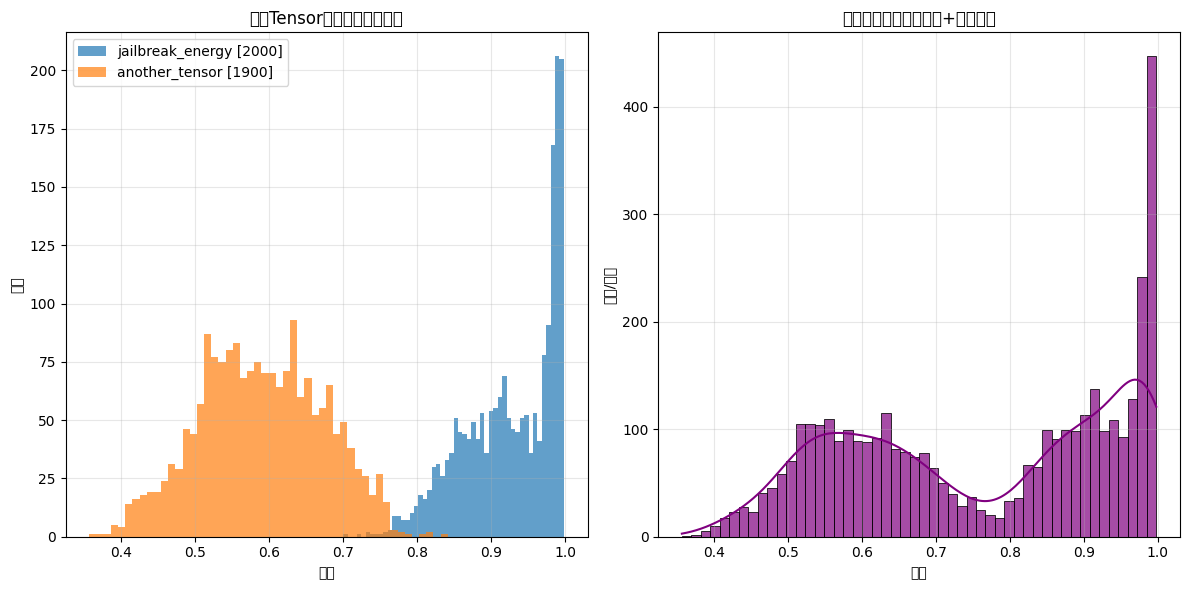

torch.Size([1869])


In [58]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # 可选，用于更美观的密度图

# -------------------
# 1. 准备数据（模拟你的两个Tensor）
# -------------------
# 假设你已有以下两个Tensor
result_jailbreak_energy = result_jailbreak_energy.cpu()
another_tensor = result_benign_energy.cpu()

# -------------------
# 2. 拼接Tensor
# -------------------
# 方法1：使用PyTorch的torch.cat
combined_tensor = torch.cat([result_jailbreak_energy, another_tensor], dim=0)
print(f"拼接后形状: {combined_tensor.shape}")  # 应为 [3900]

# 转换为NumPy数组以便可视化（Matplotlib不直接支持Tensor）
combined_np = combined_tensor.numpy()


# -------------------
# 3. 可视化分布
# -------------------
plt.figure(figsize=(12, 6))

# 子图1：直方图（展示频率分布）
plt.subplot(1, 2, 1)
plt.hist(result_jailbreak_energy.numpy(), bins=50, alpha=0.7, label="jailbreak_energy [2000]")
plt.hist(another_tensor.numpy(), bins=50, alpha=0.7, label="another_tensor [1900]")
plt.title("两个Tensor的分布（直方图）")
plt.xlabel("数值")
plt.ylabel("频率")
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2：拼接后的整体分布（密度图 + 直方图）
plt.subplot(1, 2, 2)
# 使用Seaborn绘制更美观的密度图（可选）
sns.histplot(combined_np, bins=50, kde=True, color="purple", alpha=0.7)
plt.title("拼接后整体分布（密度+直方图）")
plt.xlabel("数值")
plt.ylabel("密度/频率")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tensor_distribution.png", dpi=300)  # 保存图片
plt.show()
print(result_benign_energy.shape)

In [41]:
activation.shape,test_questions.shape

(torch.Size([2000, 3584]), torch.Size([805, 3584]))

In [37]:
activation.shape

torch.Size([2000, 3584])

In [38]:
s, p, steer1 = gate.decide(activation)
s, p, steer2 = gate.decide(test_questions)

In [39]:
steer1.sum(), steer2.sum()

(tensor(1994, device='cuda:0'), tensor(24, device='cuda:0'))

In [ ]:
tau = gate.current_threshold()

In [ ]:
tau

0.6774906204444853

In [40]:
# 训练后保存
torch.save(gate.state_dict(), "qwen2.5_gate.pth")

# 需要时加载到想用的 device/dtype
#gate2 = EnergyGateVK.load("gate.pth", map_location="cpu", device=VK.device, dtype=VK.dtype)


In [41]:
test_set.shape

NameError: name 'test_set' is not defined

In [42]:
gate2 = EnergyGateVK.load("qwen2.5_gate.pth", map_location="cpu", device=VK.device, dtype=VK.dtype)

In [235]:
gate2.mea

tensor([-4.0479,  1.1222,  0.9030,  ..., -4.2281, -0.3626, -2.0012],
       device='cuda:0')

In [236]:
VK.device

device(type='cuda', index=0)

In [237]:
VK.dtype

torch.float32

In [239]:
s, p, steer2 =gate2.decide(test_questions)

In [242]:
steer2.shape

torch.Size([805])